# Tech Challenge Fase 1 - Case NPS Preditivo 

## 1. Entendimento do Negócio

Uma empresa de e-commerce teve um grande aumento de demanda devido à evolução da área de compras online no cenário nacional. Contudo, esse crescimento acelerado trouxe desafios em manter a qualidade da experiência para o usuário final, e esses problemas são refletidos nos resultados do NPS, onde é possível perceber que há uma grande quantidade de respostas não satisfatórias.

O NPS (Net Promoter Score, ou Pontuação Líquida de Promotores) é uma importante variável de saída que resume a experiência do cliente e define sua relação de fidelidade com a empresa. Através dessa variável várias áreas podem se beneficiar:

- Suporte e Atendimento ao Cliente: podem identificar os principais problemas que causam atrito com o cliente e atuar em possíveis churn;
- Logística: podem buscar melhorias na entrega, previsão das datas de entrega, estratégias de escoamento de produtos nas diversas regiões;
- Princing: melhorar a precificação dos produtos e oferecer descontos;
- Marketing: segmentação de clientes para criação de campanhas mais assertivas.

De maneira geral, o NPS impacta também outras importantes variáveis para e-commerce:
- Recompra: clientes que deram boas notas de NPS (Promotores) normalmente confiam na empresa e realizam mais compras futuras.
- Boca a boca: Promotres costumam indicar a empresa para outras pessoas de maneira orgânica (sem custo), enquanto Detratores podem indicar a concorrência ou mesmo difamar a empresa.
- Market share: com o efeito dos Promotores ou Detratores, no longo prazo, é possível ter uma maior ou menor parcela de participação das compras totais do mercado.
- Indicadores complementares: a partir do NPS é possível derivar outras variáveis de qualidade do serviço: comparação de NPS periódico ou da concorrência (benchmark), SLA logístico (entrega no prazo x atrasados), taxa de devolução.

## 2. Definição da Target

Iniciando uma análise superficial do dataset com os resultados de NPS `../data/desafio_nps_fase_1.csv`, podemos identificar que a variável target que representa a satisfação do cliente é o **`nps_score`**. Ela precisa ser a variável target pois é a pontuação final definida pelo cliente na pesquisa de satisfação. No caso do cenário atual que estamos trabalhando, essa variável é coletada no final da experiência de uma compra.

Um risco que devemos levar em consideração é justamente o momento da coleta: final da jornada de compra. É uma pesquisa reativa em que geralmente apenas clientes insatisfeitos ou que tiveram algum tipo de problema respondem. Portanto, os dados podem estar enviesados com informações em sua maioria negativas e podem não refletir a real situação reputacional da empresa quando comparado ao todo. Ou seja, se uma pesquisa de NPS possui 500 casos e, desses, 100% são detratores, pode ser que apenas 500 casos não sejam realmente um problema se o total de compras da empresa está na casa dos milhões. Por isso, é importante ter cuidado ao realizar a análise dos dados.

## 3. Análise Exploratória dos Dados (EDA)

Vamos iniciar a EDA, verificando os dados disponíveis no dataset, compreendendo as variáveis e casos e observando a integridade do conjunto do dados disponíveis.

### Verificação das características e integridade do dataset

In [1]:
import pandas as pd

df = pd.read_csv('../data/desafio_nps_fase_1.csv')
df.head(10)

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9
5,6,35,Sudeste,75,50006,568.76,6,36.58,3,4,5,41.82,2,2,3,0.9,0,5,1.5
6,7,37,Sudeste,68,50007,41.29,3,99.62,6,8,3,35.83,3,3,4,1.4,0,6,0.6
7,8,60,Sul,37,50008,428.76,4,29.54,10,11,5,44.50,1,0,2,0.0,0,2,4.1
8,9,40,Sul,60,50009,121.56,3,91.95,6,6,3,24.88,2,1,9,6.2,0,3,0.8
9,10,51,Sudeste,70,50010,411.01,6,37.47,3,9,2,30.59,1,0,7,2.7,0,2,4.2


A visualização primária das características do dataset nos mostra a presença de 19 variáveis. Dessas variáveis, temos a seguinte classificação:
- qualitativas nominais:
  - custom_id, order_id, customer_region, repeat_purchase_30d
- quantitativas discretas:
  - customer_age, customer_tenure_months, items_quantity, payment_installments, delivery_time_days, delivery_delay_days, delivery_attempts, customer_service_contacts, resolution_time_days, complaints_count,
- quantitativas contínuas:
  - order_value, discount_value, freight_value, nps_score, csat_internal_score  

Essa abordagem irá facilitar nossa análise posterior, visto que cada tipo de variável suscita uma forma diferente de abordagem na análise exploratória

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   object 
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64

Com base nas informações apresentadas sobre o dataset, identificamos 2500 casos, sendo todos eles não nulos. Ou seja, para cada um dos casos, os dados de todas as variáveis são existentes. Como nossa abordagem inicial perpassa apenas a análise descritiva dos dados e possuímos um dataset realtivamente pequeno, optamos por não colher amostras em um primeiro momento e lidar com o dataset completo, para compreender melhor os padrões iniciais que guiarão nossas análises futuras.

In [3]:
df.isnull().sum()

customer_id                  0
customer_age                 0
customer_region              0
customer_tenure_months       0
order_id                     0
order_value                  0
items_quantity               0
discount_value               0
payment_installments         0
delivery_time_days           0
delivery_delay_days          0
freight_value                0
delivery_attempts            0
customer_service_contacts    0
resolution_time_days         0
nps_score                    0
repeat_purchase_30d          0
complaints_count             0
csat_internal_score          0
dtype: int64

Utilizamos o teste com .isnull()sum() para garantir a não nulidade dos dados. Como o teste isnull() retorna o booleano 'false', a soma dos retornos das variáveis igual a zero indica que não há nenhum caso de nulidade entre as variáveis. 

### Análise de dados de uma variável

In [4]:
df.describe(include='all')

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00000,2500.000000,2500,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
unique,NaN,NaN,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Sul,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,521,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1250.50000,43.396000,NaN,61.322400,51250.50000,434.259740,3.470800,29.745620,6.004000,8.022000,2.187200,38.217016,2.005600,1.519600,5.485600,4.378600,0.087200,4.150400,2.941600
std,721.83216,14.888487,NaN,34.478729,721.83216,289.772497,1.687331,29.225603,3.159743,3.770411,1.454442,12.076074,0.815497,1.231512,3.458002,2.510229,0.282184,1.784223,2.378957
min,1.00000,18.000000,NaN,1.000000,50001.00000,7.760000,1.000000,0.020000,1.000000,2.000000,0.000000,2.620000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,625.75000,31.000000,NaN,31.000000,50625.75000,220.245000,2.000000,8.885000,3.000000,5.000000,1.000000,29.927500,1.000000,1.000000,2.000000,2.600000,0.000000,3.000000,0.700000
50%,1250.50000,43.000000,NaN,62.000000,51250.50000,375.515000,3.000000,20.935000,6.000000,8.000000,2.000000,38.500000,2.000000,1.000000,6.000000,4.400000,0.000000,4.000000,2.800000
75%,1875.25000,56.000000,NaN,91.000000,51875.25000,577.290000,5.000000,40.832500,9.000000,11.000000,3.000000,46.270000,3.000000,2.000000,8.000000,6.100000,0.000000,5.000000,4.800000


Considerando o problema de negócio apresentado, acreditamos que os dados logísticos e de atendimento possam ter um peso elevado sobre o nps_score. É natural que, ao expandir os negócios, haja uma sobrecarga sobre esses setores. Tentaremos entender se existe algum padrão relevante de segmentação dos dados dos clientes e como os dados da encomenda podem impactar o nps_score, de modo a pensar em possíveis mecanismos de compensação para os clientes.

#### Dados do cliente

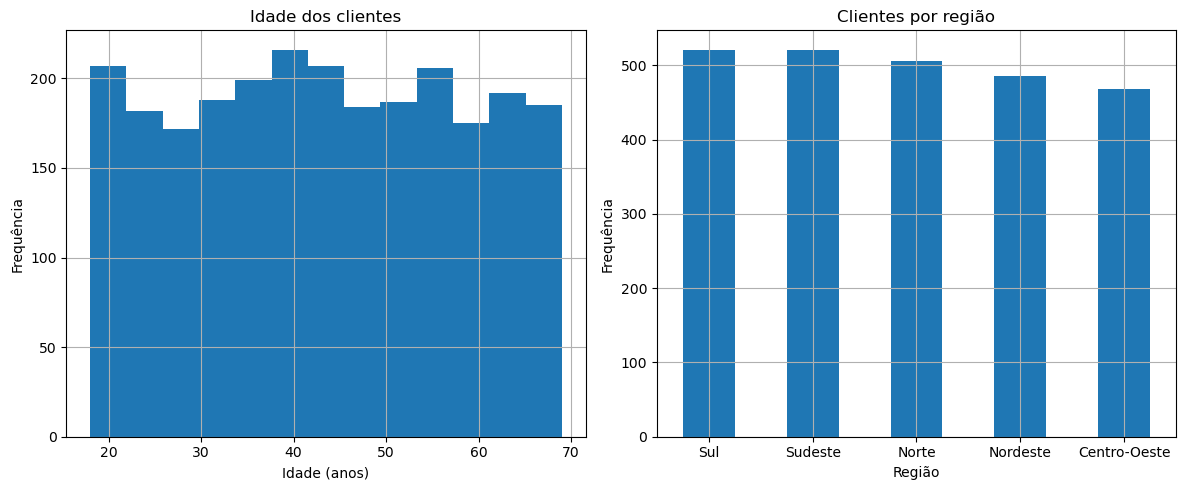

In [5]:
import matplotlib.pyplot as plt

#Grades do plot
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico 1, contendo o histograma dos dados de idade dos cliente. Testamos alguns bins e o 10 nos pareceu mais apresentável
df['customer_age'].hist(bins=13, ax = axs[0])
axs[0].set_title('Idade dos clientes')
axs[0].set_xlabel('Idade (anos)')
axs[0].set_ylabel('Frequência')
axs[0].grid(True)

# Gráfico 2, contendo a frequência por região geográfica. Utilizamos o tick_params para manter os rótulos das barras na horizontal
region_counts = df['customer_region'].value_counts().plot(kind='bar')
axs[1].set_title('Clientes por região')
axs[1].set_xlabel('Região')
axs[1].set_ylabel('Frequência')
axs[1].grid(True)
axs[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

Não encontramos padrões iniciais muito relevantes nas idades. Nenhuma faixa etária especifíca nos chamou a atenção, em termos da concentração de clientes. Em relação às regiões, a diferença entre a frequência dos clientes do Sul e do Centro-Oeste, regiões com mais e menos clientes, respectivamente, é inferior a 100 pessoas. Isso também não nos pareceu uma diferença muito relevante, em relação à quantidade total de clientes.

#### Dados da encomenda

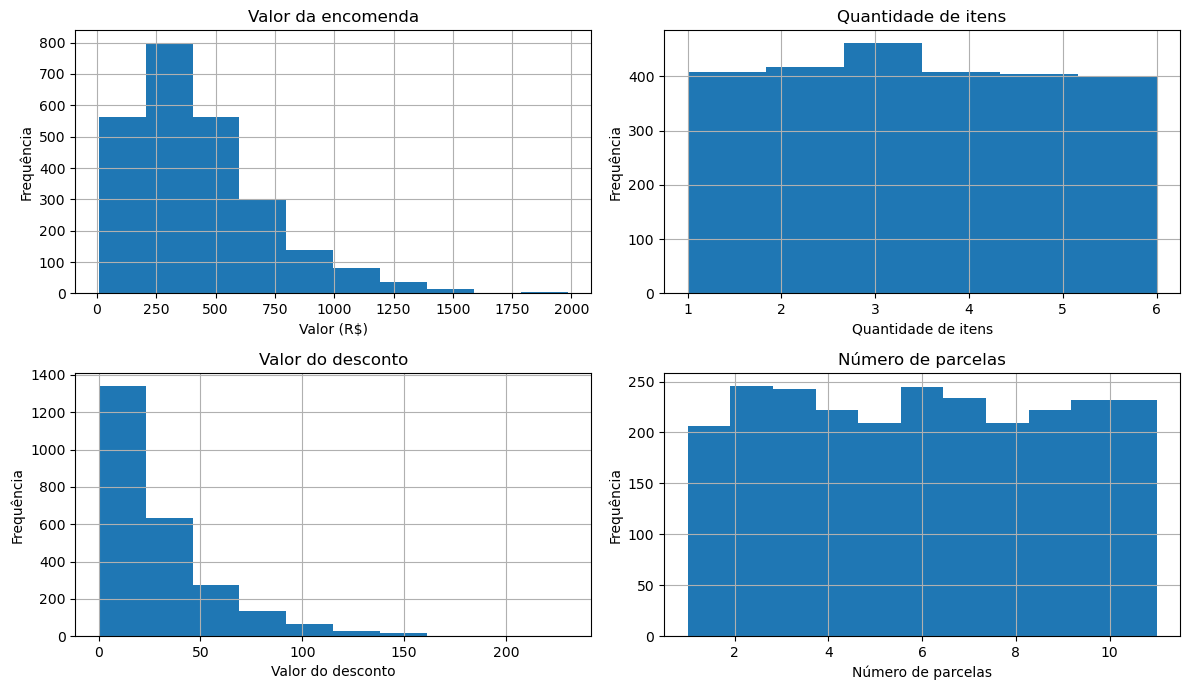

In [6]:
#Grades do plot em duas linhas e duas colunas
fig, axs = plt.subplots(2, 2, figsize=(12, 7))

# Gráfico 3, contendo o histograma dos dados de idade dos cliente. Testamos alguns bins e o 10 nos pareceu mais apresentável
df['order_value'].hist(bins=10, ax = axs[0,0])
axs[0,0].set_xlabel('Valor (R$)')
axs[0,0].set_ylabel('Frequência')
axs[0,0].set_title('Valor da encomenda')
axs[0,0].grid(True)

# Gráfico 4, contendo o histograma da quantidade de itens por compra
df['items_quantity'].hist(bins=6, ax = axs[0,1])
axs[0,1].set_xlabel('Quantidade de itens')
axs[0,1].set_ylabel('Frequência')
axs[0,1].set_title('Quantidade de itens')
axs[0,1].grid(True)

# Gráfico 5, contendo o histograma dos valores de desconto no valor do produto
df['discount_value'].hist(bins=10, ax = axs[1,0])
axs[1,0].set_xlabel('Valor do desconto')
axs[1,0].set_ylabel('Frequência')
axs[1,0].set_title('Valor do desconto')
axs[1,0].grid(True)

# Gráfico 6, contendo os dados de número de parcelas. Pelo fato de ser uma variável discreta, optamos por utilizar o valor máximo dela no número de bins
df['payment_installments'].hist(bins=11, ax = axs[1,1])
axs[1,1].set_xlabel('Número de parcelas')
axs[1,1].set_ylabel('Frequência')
axs[1,1].set_title('Número de parcelas')
axs[1,1].grid(True)


plt.tight_layout()
plt.show()

A princípio, não inferimos nada de relevante sobre o número de parcelas e a quantidade de itens, visualizando apenas o histograma. Os gráficos de valor da encomenda e valor de desconto apresentam assimetria, concentrando a maior parte dos casos em valores abaixo da média. Essa distribuição corrobora os dados obtidos nos cálculos de média e mediana. Para ambas variáveis, o valor da mediana foi inferior ao da média, indicando a assimetria observada graficamente.

#### Dados logísticos

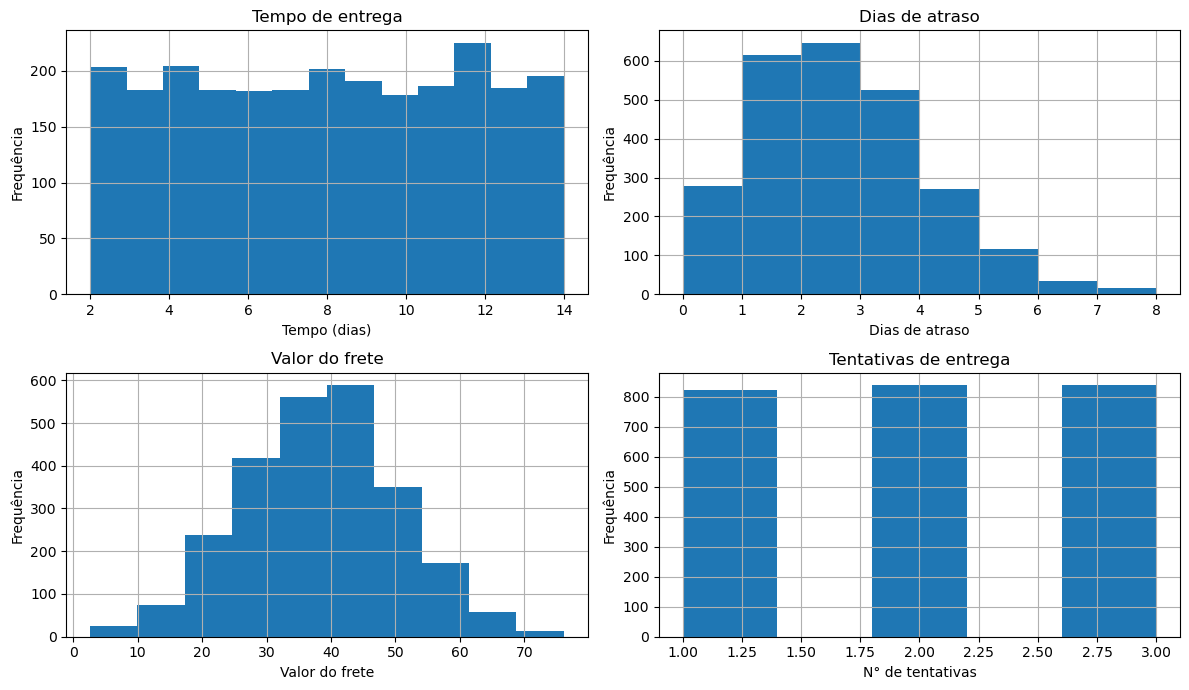

In [ ]:
#Grades do plot em duas linhas e duas colunas
fig, axs = plt.subplots(2, 2, figsize=(12, 7))

# Gráfico 7, contendo o histograma do nº de dias para entrega do pedido
df['delivery_time_days'].hist(bins=13, ax = axs[0,0])
axs[0,0].set_xlabel('Tempo (dias)')
axs[0,0].set_ylabel('Frequência')
axs[0,0].set_title('Tempo de entrega')
axs[0,0].grid(True)

# Gráfico 8, contendo o histograma dos dias de atraso na entrega
df['delivery_delay_days'].hist(bins=8, ax = axs[0,1])
axs[0,1].set_xlabel('Dias de atraso')
axs[0,1].set_ylabel('Frequência')
axs[0,1].set_title('Dias de atraso')
axs[0,1].grid(True)

# Gráfico 9, contendo o histograma dos valores de frete
df['freight_value'].hist(bins=10, ax = axs[1,0])
axs[1,0].set_xlabel('Valor do frete')
axs[1,0].set_ylabel('Frequência')
axs[1,0].set_title('Valor do frete')
axs[1,0].grid(True)

# Gráfico 10, contendo o histograma do número de tentativas de entrega
df['delivery_attempts'].hist(bins=5, ax = axs[1,1])
axs[1,1].set_xlabel('N° de tentativas')
axs[1,1].set_ylabel('Frequência')
axs[1,1].set_title('Tentativas de entrega')
axs[1,1].grid(True)


plt.tight_layout()
plt.show()

In [14]:
df['delivery_attempts'].value_counts()

delivery_attempts
3    838
2    838
1    824
Name: count, dtype: int64

O histograma de entrega mostra 3 barras quase idênticas, o que evidencia que a empresa usa o padrão de 3 tentativas antes de cancelar a entrega. Através da tabela verificamos que a soma das três tentativas foi igual a 2500, o que significa que todas as encomendas foram entregues. O histograma do tempo de entrega nos mostra dados entre 2 e 14 dias, mas bem próximos entre si, pensando na quantidade de entregas. Não foi observado padrão de sino neste histograma. Já os histogramas de dias de atraso e valor do frete apresentam forma de sino, sendo o primeiro assimétrico, enquanto o segundo lembra uma distribuição normal. Achamos relevante o fato de que embora os dados de tempo de entrega sejam distribuídos de forma mais ou menos uniforme entre os dias, os dados de atraso se concentram mais em torno de 2 a 3 dias. Esse fato nos suscitou a ideia de buscar uma correção para os dias de entrega, como forma de amenizar os possíveis efeitos do atraso sobre o NPS. Na análise de duas variáveis, voltaremos aos dados de entrega para compreender melhor sua relação com o nps_score. 

#### Dados de atendimento

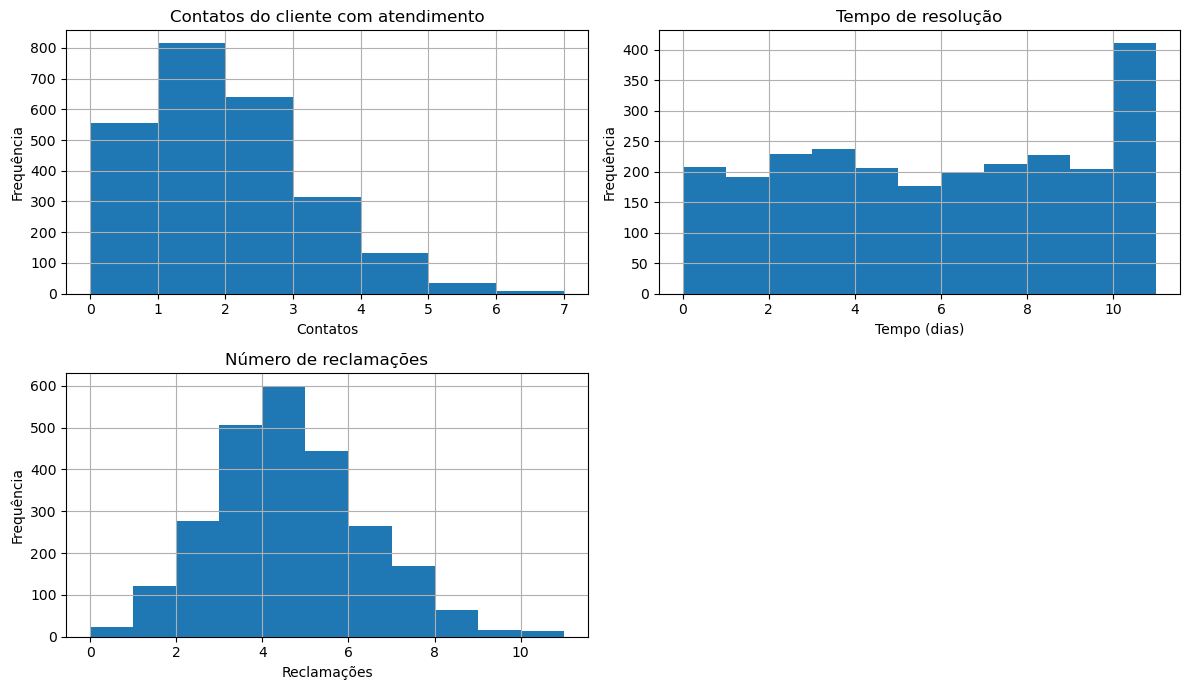

In [21]:
#Grades do plot em duas linhas e duas colunas
fig, axs = plt.subplots(2, 2, figsize=(12, 7))

# Gráfico 11, contendo o histograma do nº de contatos do cliente com o atendimento
df['customer_service_contacts'].hist(bins=7, ax = axs[0,0])
axs[0,0].set_xlabel('Contatos')
axs[0,0].set_ylabel('Frequência')
axs[0,0].set_title('Contatos do cliente com atendimento')
axs[0,0].grid(True)

# Gráfico 12, contendo o histograma dos dias que demoram para a resolução das demandas dos clientes
df['resolution_time_days'].hist(bins=11, ax = axs[0,1])
axs[0,1].set_xlabel('Tempo (dias)')
axs[0,1].set_ylabel('Frequência')
axs[0,1].set_title('Tempo de resolução')
axs[0,1].grid(True)

# Gráfico 13, contendo o histograma do número de reclamações
df['complaints_count'].hist(bins=11, ax = axs[1,0])
axs[1,0].set_xlabel('Reclamações')
axs[1,0].set_ylabel('Frequência')
axs[1,0].set_title('Número de reclamações')
axs[1,0].grid(True)

axs[1,1].axis('off')
plt.tight_layout()
plt.show()

Percebemos padrões de sino nos histogramas de contatos e de reclamações. O histograma de número de reclamações apresenta um padrão visual parecido com uma curva normal. A concentratação de dados de reclamações em torno de 4 nos mostra uma quantidade relevante de clientes insatisfeitos. O tempo de resolução elevado, com mais de 400 cliente acima de 10 dias, evidencia a dificuldade do atendimento em lidar com as demandas dos cliente, em um cenário de alta demanda e atrasos constantes de entrega.

#### Dados de satisfação

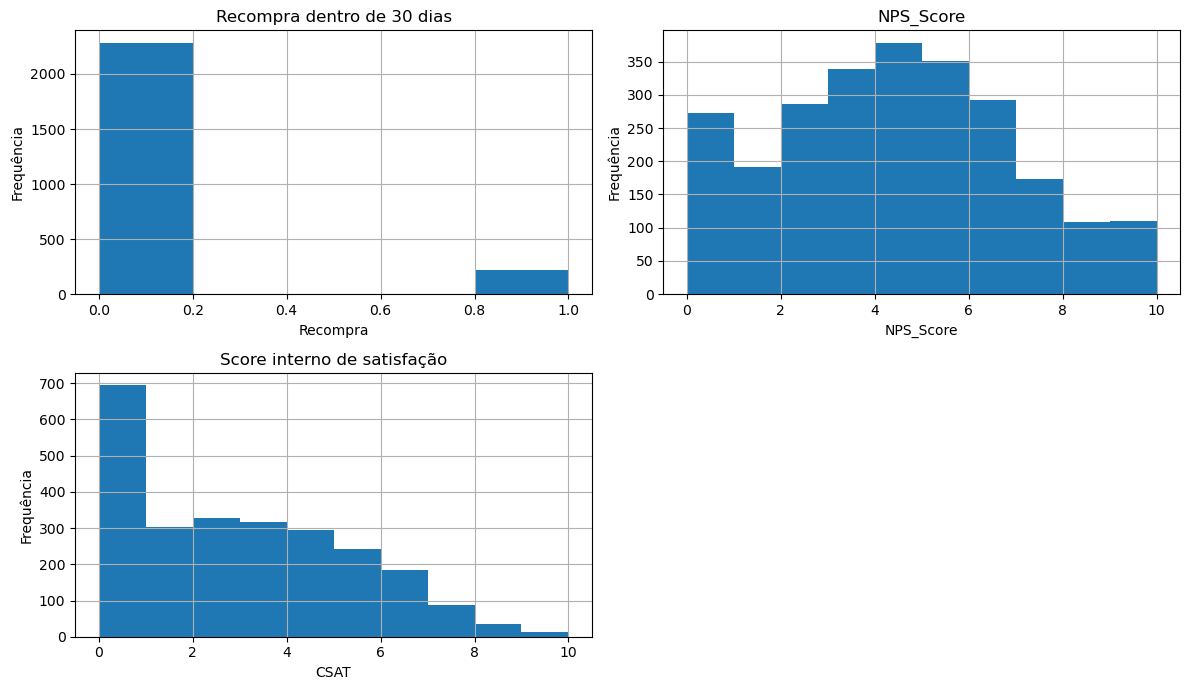

In [22]:
#Grades do plot em duas linhas e duas colunas
fig, axs = plt.subplots(2, 2, figsize=(12, 7))

# Gráfico 14, contendo o histograma das recompras dentro de um mês
df['repeat_purchase_30d'].hist(bins=5, ax = axs[0,0])
axs[0,0].set_xlabel('Recompra')
axs[0,0].set_ylabel('Frequência')
axs[0,0].set_title('Recompra dentro de 30 dias')
axs[0,0].grid(True)

# Gráfico 15, contendo o histograma dos NPS_Score
df['nps_score'].hist(bins=10, ax = axs[0,1])
axs[0,1].set_xlabel('NPS_Score')
axs[0,1].set_ylabel('Frequência')
axs[0,1].set_title('NPS_Score')
axs[0,1].grid(True)

# Gráfico 16, contendo o histograma dos dados de CSAT
df['csat_internal_score'].hist(bins=10, ax = axs[1,0])
axs[1,0].set_xlabel('CSAT')
axs[1,0].set_ylabel('Frequência')
axs[1,0].set_title('Score interno de satisfação')
axs[1,0].grid(True)

axs[1,1].axis('off')
plt.tight_layout()
plt.show()

A distribuçao dos dados de recompra apresenta uma concentração de menos de 300 pessoas entre os que recompraram. Podemos perceber no histograma do nps_score que o número de pessoas com notas 9 e 10 também foi abaixo de 300. É possível e até natural que exista uma relação entre notas altas e recompra. O histograma de CSAT apresenta uma concentração maior de casos na primeira metade do gráfico, corroborando os dados de média e mediana apresentados anteriormente. O CSAT e o nps_score apresentaram histogramas assimétricos com medianas inferiores às médias. Isso evidencia uma concentratação maior de dados em valores mais baixos. No entanto, comparandos as duas variáveis, percebemos que o CSAT apresenta em média, valores mais baixos que o nps_score. Isso pode indicar a presença de clientes com um histórico de relacionamento com a empresa, mas que demonstraram insatisfação através dos últimos pontos de contato com a mesma. Isso sugere que, caso os problemas gerados pelo aumento de demanda permaneçam, isso possivelmente terá um efeito deletério sobre o NPS.  

Na próxima etapa de análise, verificaremos o impacto das variáveis sobre o nps_score. Em especial, buscaremos relações entre os dados logísticos e de atendimento para compreender como os atraso elevado e as dificuldades de resolução de problemas do cliente no atendimento, observados nos histogramas, se correlacionam com os dados de satisfação. Iremos analisar também se existe impacto dos preços dos produtos, dos descontos e dos valores de frete sobre o nps_score, para entendermos se possíveis descontos podem auxiliar no aumento da satisfação do cliente. Por último, buscaremos padrões de segmentação dos clientes para entendermos se trabalhar pontualmente com faixas etárias ou regiões geográficas específicas pode ter impacto relevante sobre o NPS.

### Análise de dados de duas variáveis

In [23]:
# Função para segmentar o NPS em faixas. 
# Optamos por segmentar os detratores em 3 faixas, para melhor observar o impacto das variáveis de entrada sobre o nps_score
def calcula_faixa_NPS(score):
  if score <= 2:
    return '[0-2]'
  if score <= 4 and score>2:
    return '[2-4]'
  if score <=6 and score > 4:
    return '[4-6]'
  if score <=9 and score >6:
    return '[6-9]'
  return '[9-10]'

# Com base na função de segmentação, criamos uma nova variável categórica
df['faixa_NPS'] = df['nps_score'].map(calcula_faixa_NPS)

#Calculamos a porcentagem de desconto e de frete, tendo como referência o valor da encomenda.
#O objetivo é padronizar os dados de desconto e frete, para melhorar a comparação entre clientes com diferentes valores de encomenda
df['porc_desconto'] = 100*df['discount_value']/df['order_value']
df['porc_frete'] = 100*df['freight_value']/df['order_value']

#Função que segmenta cliente com e sem atraso na entrega da encomenda.
def calcula_atraso(dias):
  if(dias > 0):
    return 1
  return 0

#Criação da variável atraso, que utiliza a função calcula_atraso para segmentar os clientes
df['atraso'] = df['delivery_delay_days'].map(calcula_atraso)

# Função de segementação com base na faixa etária. Utilizamos as classificações jovem, adulto e idoso.
def calcula_faixa_etaria(anos):
  if(anos >= 60):
    return 'idoso'
  if(anos >= 30 and anos < 60):
    return 'adulto'
  return 'jovem'

#Variável faixa etária que recebe a segmentação com base na idade dos clientes
df['faixa_etaria'] = df['customer_age'].map(calcula_faixa_etaria)

df

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,...,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,faixa_NPS,porc_desconto,porc_frete,atraso,faixa_etaria
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,...,4,6.9,0,3,6.5,[6-9],28.161454,39.740929,1,idoso
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,...,10,2.4,0,3,0.0,[2-4],2.072121,6.150997,1,jovem
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,...,5,4.8,0,7,1.5,[4-6],8.444760,8.083856,1,adulto
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,...,11,5.9,0,4,0.3,[4-6],6.479367,11.661537,1,adulto
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,...,0,6.1,0,3,7.9,[6-9],11.605943,15.537817,1,adulto
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,2496,51,Sul,96,52496,615.81,6,11.41,2,14,...,2,3.7,0,3,4.3,[2-4],1.852844,4.702749,1,adulto
2496,2497,37,Sul,89,52497,73.03,1,36.44,3,12,...,7,3.7,0,4,2.5,[2-4],49.897302,37.546214,1,adulto
2497,2498,19,Sudeste,98,52498,522.78,1,4.84,9,2,...,1,7.4,0,3,6.2,[6-9],0.925820,7.448640,1,jovem
2498,2499,41,Sul,51,52499,55.87,2,2.11,2,14,...,0,2.3,0,5,1.7,[2-4],3.776624,52.085198,1,adulto


<Axes: xlabel='customer_region'>

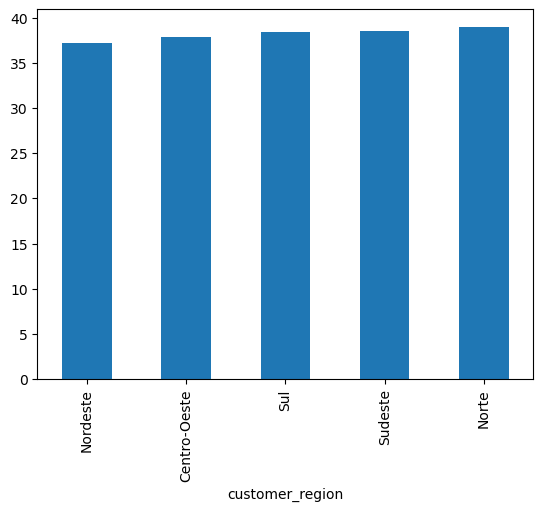

In [30]:
df.groupby('customer_region')['freight_value'].mean().sort_values(ascending=True).plot(kind='bar', x='customer_region', y='freight_value')

In [32]:
df.groupby('faixa_NPS')['customer_age'].mean().sort_values(ascending=True)

faixa_NPS
[2-4]     42.791139
[4-6]     43.164609
[9-10]    43.542857
[6-9]     43.661765
[0-2]     44.193878
Name: customer_age, dtype: float64

<Axes: xlabel='faixa_NPS'>

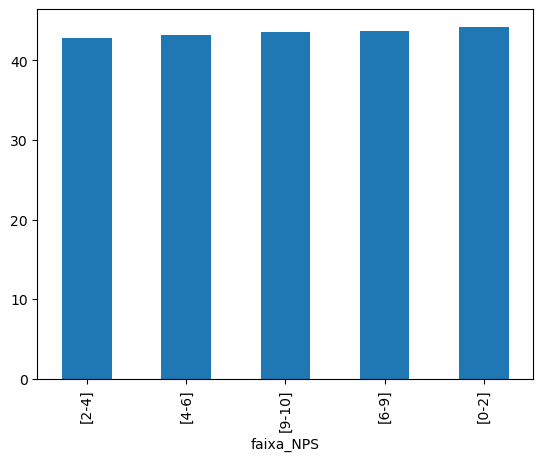

In [33]:
df.groupby('faixa_NPS')['customer_age'].mean().sort_values(ascending=True).plot(kind='bar')